# 🏈 NFL Play Success Predictor
### Machine Learning Analysis — nflverse Play-by-Play Data

## 1. Setup & Imports

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
print('All imports successful ✅')

All imports successful ✅


## 2. Load Data

In [14]:
df = pd.read_csv('../data/processed_pbp.csv')
print(f'Shape: {df.shape}')
print(f'Success rate: {df["success"].mean():.1%}')
df.head()

Shape: (140484, 14)
Success rate: 68.4%


,posteam,defteam,play_type,yards_gained,down,ydstogo,yardline_100,game_seconds_remaining,score_differential,epa,is_pass,red_zone,late_game,success
0,SF,ARI,pass,5.0,1.0,10.0,75.0,3600.0,0.0,1.294838,1,0,0,1
1,SF,ARI,run,14.0,1.0,10.0,55.0,3582.0,0.0,0.857214,0,0,0,1
2,SF,ARI,run,2.0,1.0,10.0,41.0,3539.0,0.0,-0.454665,0,0,0,1
3,SF,ARI,run,-6.0,2.0,8.0,39.0,3501.0,0.0,-1.780660,0,0,0,0
4,SF,ARI,pass,11.0,3.0,14.0,45.0,3459.0,0.0,-0.538702,1,0,0,1


## 3. Exploratory Data Analysis

Task was destroyed but it is pending!
task: <Task pending name='Task-160' coro=<_async_in_context.<locals>.run_in_context() done, defined at /opt/homebrew/Caskroom/miniconda/base/envs/myenv/lib/python3.11/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-161' coro=<Kernel.shell_main() running at /opt/homebrew/Caskroom/miniconda/base/envs/myenv/lib/python3.11/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /opt/homebrew/Caskroom/miniconda/base/envs/myenv/lib/python3.11/site-packages/zmq/eventloop/zmqstream.py:563]>
Task was destroyed but it is pending!
task: <Task pending name='Task-161' coro=<Kernel.shell_main() running at /opt/homebrew/Caskroom/miniconda/base/envs/myenv/lib/python3.11/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]>


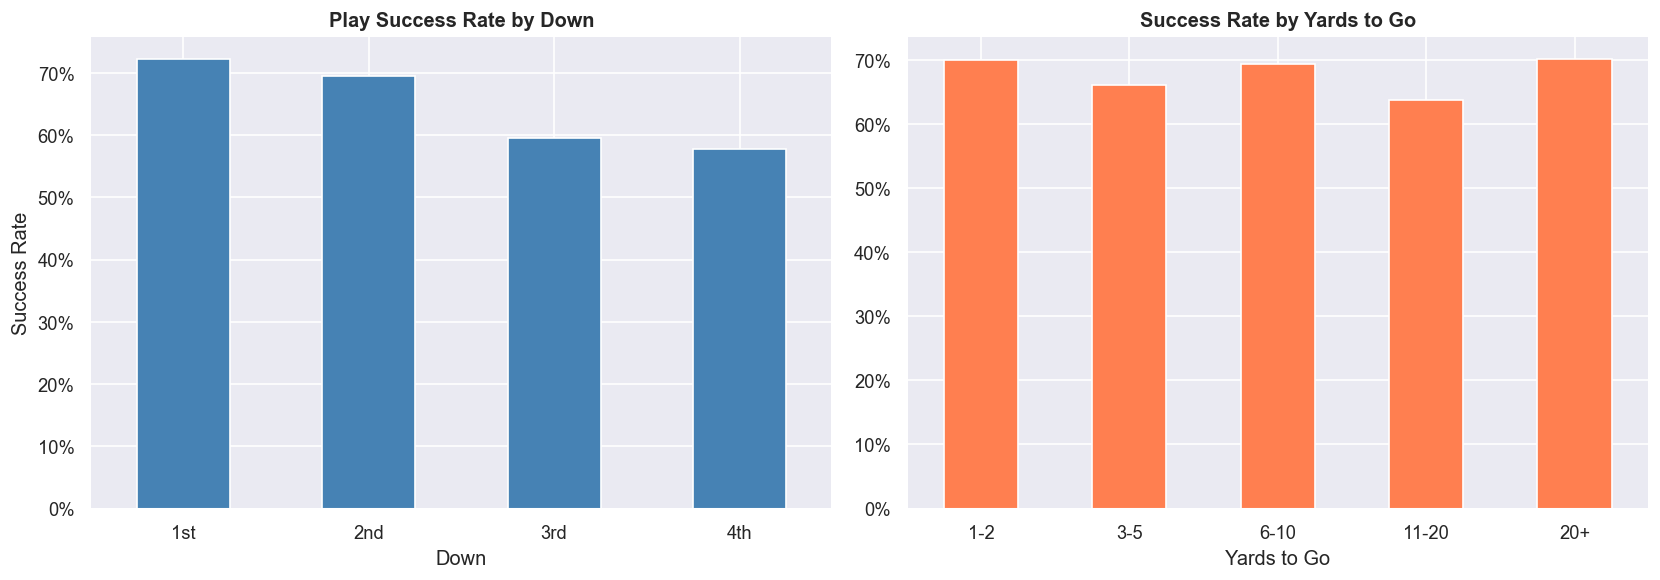

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
success_by_down = df.groupby('down')['success'].mean()
success_by_down.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Play Success Rate by Down', fontweight='bold')
axes[0].set_xlabel('Down')
axes[0].set_ylabel('Success Rate')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[0].set_xticklabels(['1st','2nd','3rd','4th'], rotation=0)
df['ydstogo_bin'] = pd.cut(df['ydstogo'], bins=[0,2,5,10,20,100], labels=['1-2','3-5','6-10','11-20','20+'])
success_by_ydstogo = df.groupby('ydstogo_bin', observed=True)['success'].mean()
success_by_ydstogo.plot(kind='bar', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Success Rate by Yards to Go', fontweight='bold')
axes[1].set_xlabel('Yards to Go')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

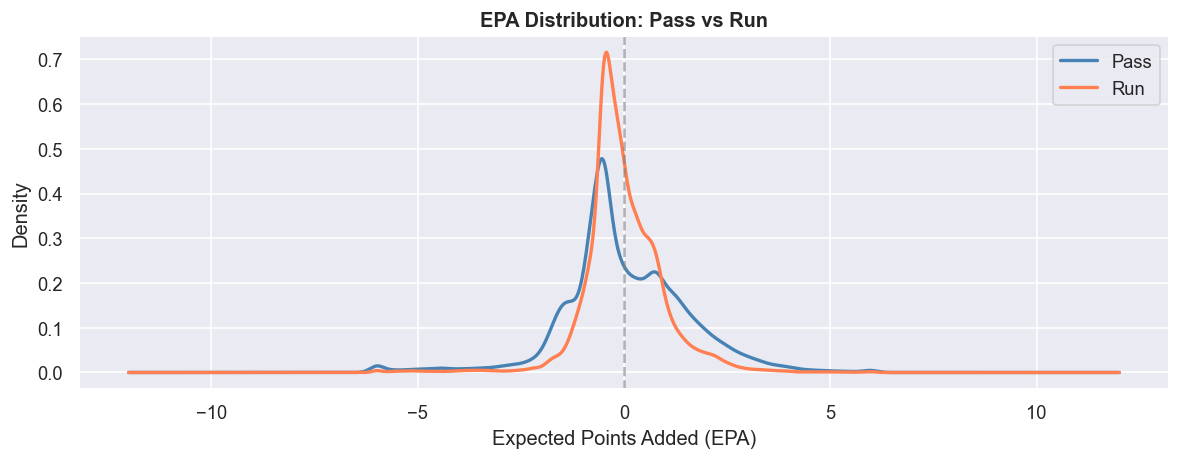

In [16]:
fig, ax = plt.subplots(figsize=(10, 4))
for play, color in [('pass', 'steelblue'), ('run', 'coral')]:
    df[df['play_type'] == play]['epa'].clip(-6, 6).plot.kde(ax=ax, label=play.capitalize(), color=color, linewidth=2)
ax.axvline(0, color='gray', linestyle='--', alpha=0.6)
ax.set_title('EPA Distribution: Pass vs Run', fontweight='bold')
ax.set_xlabel('Expected Points Added (EPA)')
ax.legend()
plt.tight_layout()
plt.show()

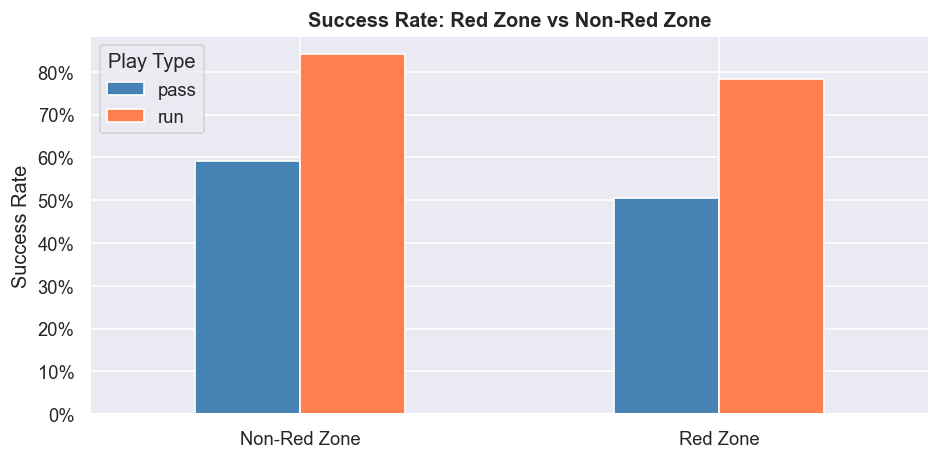

In [17]:
pivot = df.groupby(['red_zone', 'play_type'])['success'].mean().unstack()
pivot.index = ['Non-Red Zone', 'Red Zone']
pivot.plot(kind='bar', figsize=(8, 4), color=['steelblue','coral'], edgecolor='white')
plt.title('Success Rate: Red Zone vs Non-Red Zone', fontweight='bold')
plt.ylabel('Success Rate')
plt.xticks(rotation=0)
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.legend(title='Play Type')
plt.tight_layout()
plt.show()

## 4. Train the Model

In [18]:
features = ['down','ydstogo','yardline_100','score_differential','epa','is_pass','red_zone','late_game','losing_big','short_yardage']
X = df[features]
y = df['success']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
preds = model.predict(X_test)
print(f'Accuracy: {accuracy_score(y_test, preds):.3f}')
print(classification_report(y_test, preds, target_names=['No Gain','Gain']))

KeyError: "['losing_big', 'short_yardage'] not in index"

## 5. Confusion Matrix

In [ ]:
cm = confusion_matrix(y_test, preds)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Gain','Gain']).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Feature Importance

In [ ]:
importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['coral' if v == importances.max() else 'steelblue' for v in importances]
importances.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_title('Feature Importance — Random Forest', fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

## 7. Save Model

In [ ]:
import os
os.makedirs('../model', exist_ok=True)
joblib.dump(model, '../model/nfl_model.pkl')
print('Model saved ✅')

## 8. Test a Custom Play

In [ ]:
sample = pd.DataFrame([{'down':3,'ydstogo':7,'yardline_100':70,'score_differential':0,'epa':0.1,'is_pass':1,'red_zone':0,'late_game':0,'losing_big':0,'short_yardage':0}])
prob = model.predict_proba(sample)[0]
print('3rd & 7, pass play, tied game:')
print(f'  No Gain: {prob[0]:.1%}')
print(f'  Gain:    {prob[1]:.1%}')